# CML3014N Assignment 2

```
EDA
1. Load data
2. check variable type
3. check missing value
4. fill missing value (if any)
5. find and remove outlier (not sure which step)
5. one-hot / label encoding (if needed)
6. identify relationship using corr() / draw regplot
7. choose features
8. split train test
9. feature scaling (-1, 1), StandardScaler on input x, train use fit_transform, test use tranform
```
```
Build ANN
xxx
```






In [ ]:
pip install ucimlrepo

# Load Data and EDA

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets

# metadata
print(covertype.metadata)

# variable information
print(covertype.variables)


{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [ ]:
X

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,1,0
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,1,0
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,1,0
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
y

,Cover_Type
0,5
1,5
2,2
3,2
4,5
...,...
581007,3
581008,3
581009,3
581010,3


In [ ]:
y_series = y['Cover_Type']
print(y_series.unique())
print(y_series.value_counts())

[5 2 1 7 3 6 4]
Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64


In [ ]:
X.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
y.isnull().sum()

,0
Cover_Type,0


# Spilt Numerical and Categorical Categories

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Soil_Type1                          581012 non-null 

In [ ]:
# Numerical features: first 10 columns
X_num = X.iloc[:, :10]

# Categorical one-hot features: remaining columns
X_cat = X.iloc[:, 10:]

print("X Numerical")
X_num

X Numerical


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
0,2596,51,3,258,0,510,221,232,148,6279
1,2590,56,2,212,-6,390,220,235,151,6225
2,2804,139,9,268,65,3180,234,238,135,6121
3,2785,155,18,242,118,3090,238,238,122,6211
4,2595,45,2,153,-1,391,220,234,150,6172
...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837
581008,2391,152,19,67,12,95,240,237,119,845
581009,2386,159,17,60,7,90,236,241,130,854
581010,2384,170,15,60,5,90,230,245,143,864


In [ ]:
print("X Categorical")
X_cat

X Categorical


,Wilderness_Area1,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
581008,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
581009,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
581010,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


# Numerical & Categorical Features Plot

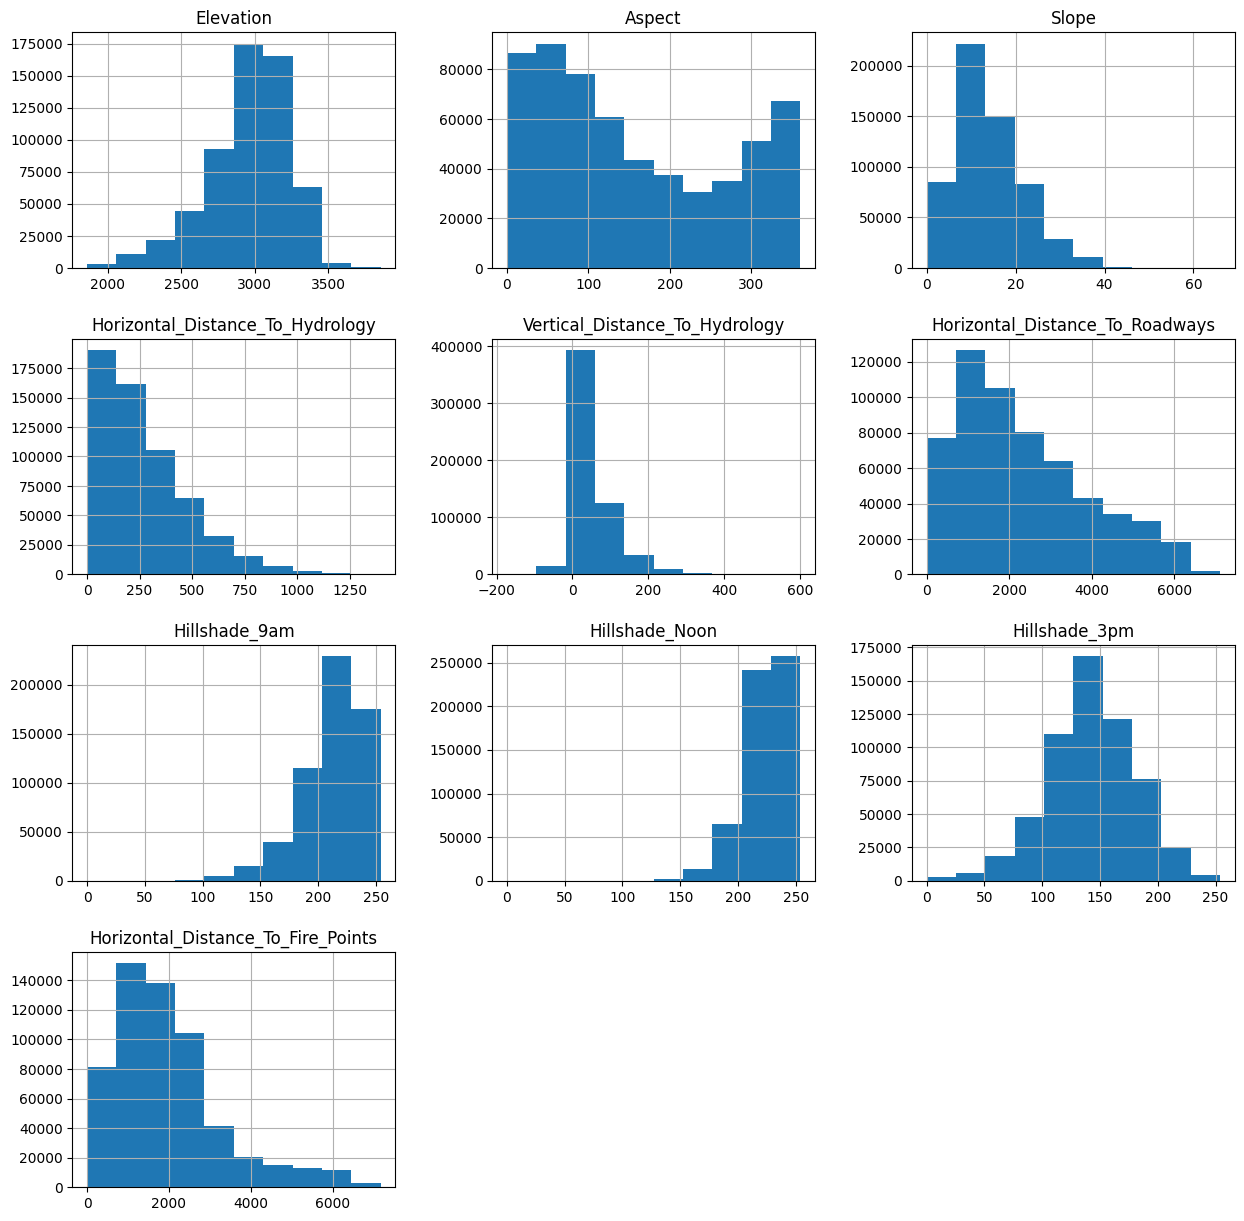

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Histograms for numerical features
X_num.hist(figsize=(15,15))
plt.show()

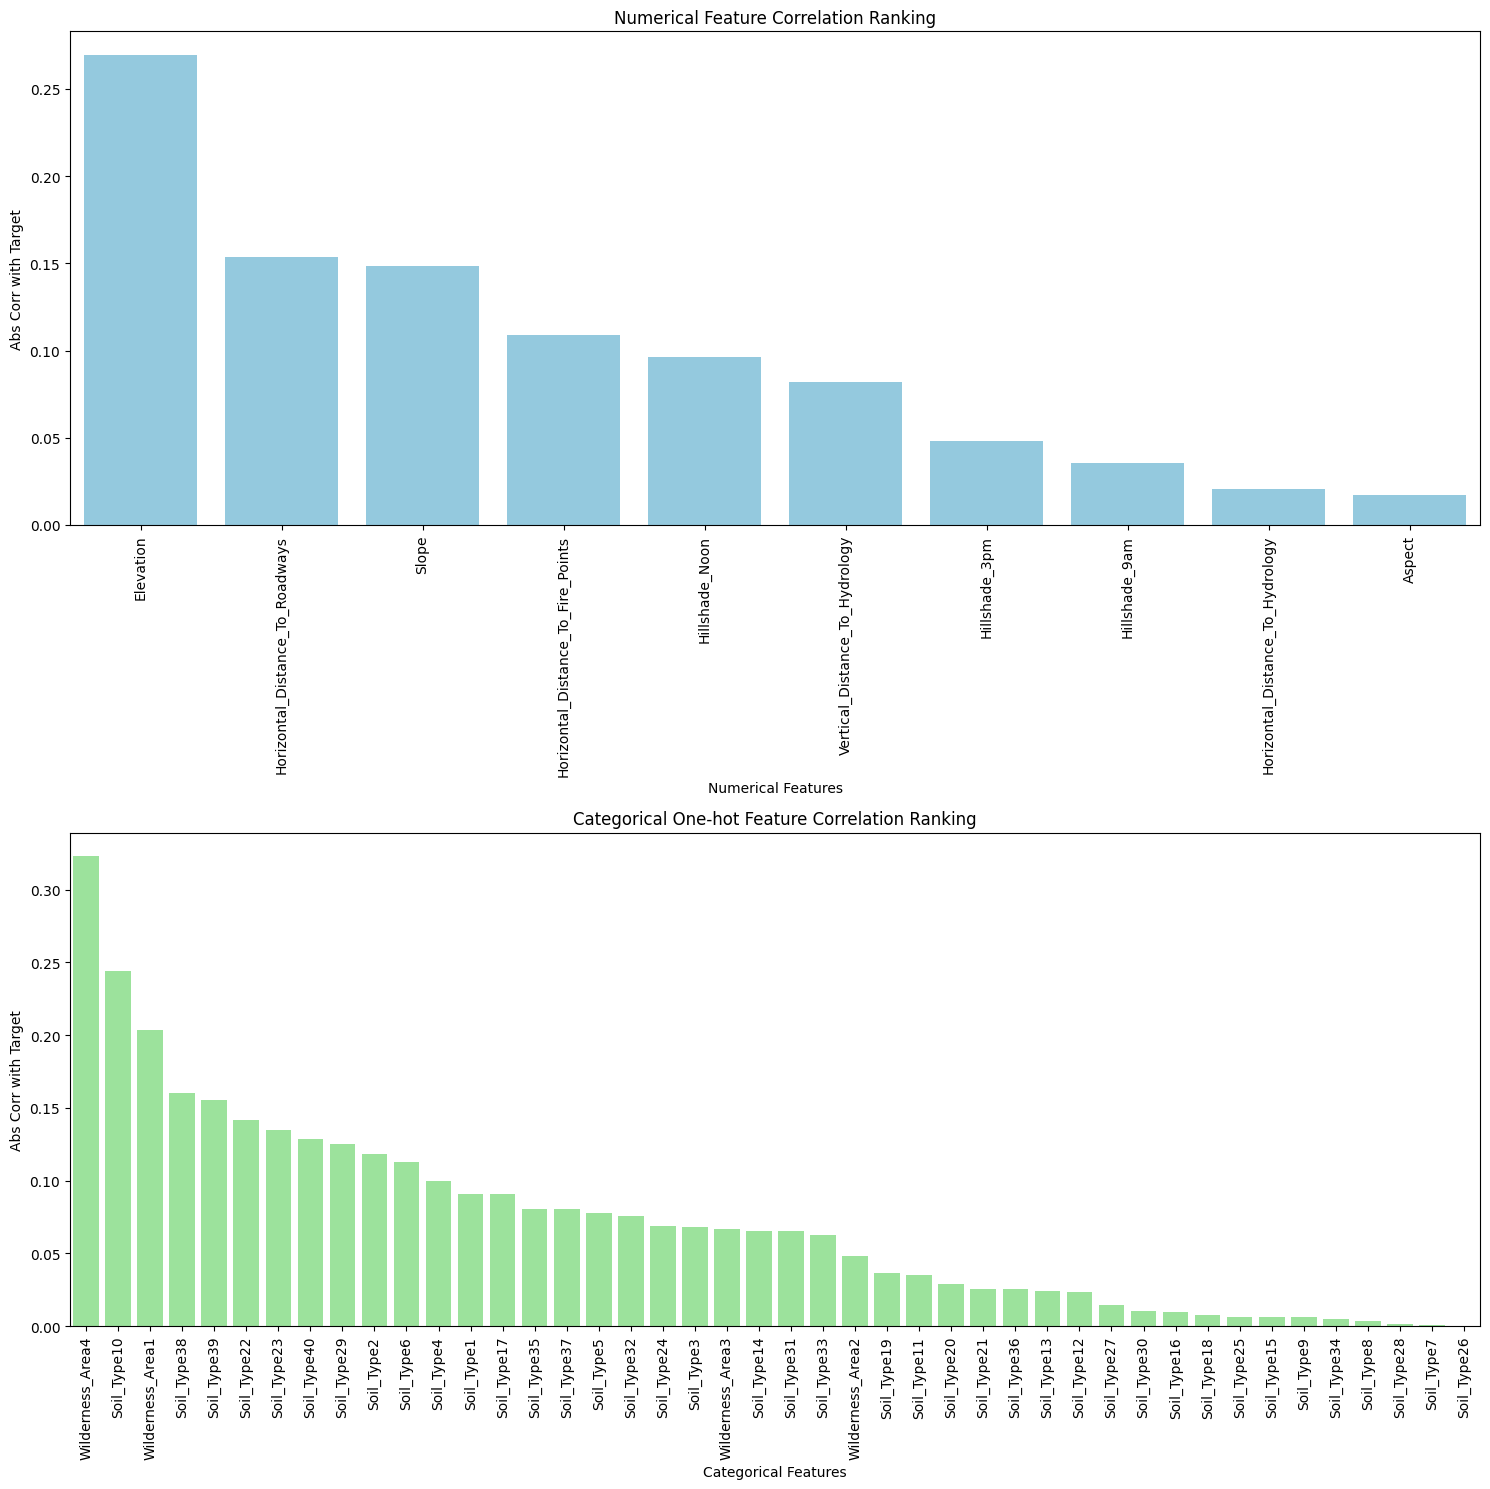

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 1D target
y_1d = y.squeeze()

# Combine features
X_all = pd.concat([X_num, X_cat], axis=1)

# Compute absolute correlation with target
corr_with_target = X_all.join(y_1d.rename('Target')).corr()['Target'].abs()
corr_with_target = corr_with_target.drop('Target')

# Separate numerical vs categorical
num_corr = corr_with_target[X_num.columns].sort_values(ascending=False)
cat_corr = corr_with_target[X_cat.columns].sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(15,15))

# Numerical features
sns.barplot(x=num_corr.index, y=num_corr.values, ax=axes[0], color='skyblue')
axes[0].set_ylabel("Abs Corr with Target")
axes[0].set_xlabel("Numerical Features")
axes[0].set_title("Numerical Feature Correlation Ranking")
axes[0].tick_params(axis='x', rotation=90)

# Categorical features
sns.barplot(x=cat_corr.index, y=cat_corr.values, ax=axes[1], color='lightgreen')
axes[1].set_ylabel("Abs Corr with Target")
axes[1].set_xlabel("Categorical Features")
axes[1].set_title("Categorical One-hot Feature Correlation Ranking")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


# Remove outlier

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd

# Combine numerical + categorical for outlier detection
X_combined = pd.concat([X_num, X_cat], axis=1)

# Detect outliers using IsolationForest
iso = IsolationForest(
    n_estimators=300,
    contamination=0.01,   # expected % of outliers
    random_state=42
)
iso.fit(X_combined)

labels = iso.predict(X_combined)        # -1 = outlier, 1 = inlier
mask = labels == 1                      # True for inliers

# Remove outliers
X_num_no_outliers = X_num[mask].copy()
X_cat_no_outliers = X_cat[mask].copy()
y_no_outliers = y[mask].copy()

In [ ]:
X_num_no_outliers

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
0,2596,51,3,258,0,510,221,232,148,6279
1,2590,56,2,212,-6,390,220,235,151,6225
2,2804,139,9,268,65,3180,234,238,135,6121
3,2785,155,18,242,118,3090,238,238,122,6211
4,2595,45,2,153,-1,391,220,234,150,6172
...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837
581008,2391,152,19,67,12,95,240,237,119,845
581009,2386,159,17,60,7,90,236,241,130,854
581010,2384,170,15,60,5,90,230,245,143,864


In [ ]:
X_cat_no_outliers

,Wilderness_Area1,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
581008,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
581009,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
581010,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
y_no_outliers

,Cover_Type
0,5
1,5
2,2
3,2
4,5
...,...
581007,3
581008,3
581009,3
581010,3


# Select features based on correlation

In [ ]:
# Compute absolute correlation with target (global ranking)
X_no_outliers = pd.concat([X_num_no_outliers, X_cat_no_outliers], axis=1)
y_no_outliers = y_no_outliers.squeeze()

# Pick top N features globally
top_N = 20
top_features = corr_with_target.index[:top_N]

# Separate numerical vs categorical
num_sel = [f for f in top_features if f in X_num_no_outliers.columns]
cat_sel = [f for f in top_features if f in X_cat_no_outliers.columns]

print("Top numerical features selected:", num_sel)
print("Top categorical features selected:", cat_sel)

Top numerical features selected: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
Top categorical features selected: ['Wilderness_Area1', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9']


# Scaling using StandardScaler (Scale numerical features only)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Scale numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_no_outliers[num_sel])

# Keep categorical as one-hot encoded
X_cat_sel = X_cat_no_outliers[cat_sel].values

# Combine scaled numerical + categorical features
X_sc = np.hstack([X_num_scaled, X_cat_sel])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y_no_outliers, test_size=0.2, random_state=42
)

print("Preprocessing complete. Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Preprocessing complete. Shapes:
X_train: (460160, 20)
X_test : (115041, 20)
y_train: (460160,)
y_test : (115041,)


# Step 1 Baseline MLP
1. 3 hidden layers
- removed outlier
- adam optimizer, relu activation function, batch size 32, epoch 23 with earlystoping patience 2
- accuracy 0.93

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()
model.add(Dense(256, activation='relu', input_dim= X_train.shape[1]))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(8, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,048 (183.78 KB)

 Trainable params: 47,048 (183.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stp = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=early_stp, validation_split=0.2, verbose=2)

Epoch 1/100
11504/11504 - 33s - 3ms/step - accuracy: 0.7620 - loss: 0.5509 - val_accuracy: 0.8008 - val_loss: 0.4643
Epoch 2/100
11504/11504 - 30s - 3ms/step - accuracy: 0.8158 - loss: 0.4319 - val_accuracy: 0.8317 - val_loss: 0.4012
Epoch 3/100
11504/11504 - 31s - 3ms/step - accuracy: 0.8404 - loss: 0.3784 - val_accuracy: 0.8413 - val_loss: 0.3733
Epoch 4/100
11504/11504 - 31s - 3ms/step - accuracy: 0.8569 - loss: 0.3435 - val_accuracy: 0.8636 - val_loss: 0.3295
Epoch 5/100
11504/11504 - 30s - 3ms/step - accuracy: 0.8667 - loss: 0.3203 - val_accuracy: 0.8700 - val_loss: 0.3123
Epoch 6/100
11504/11504 - 30s - 3ms/step - accuracy: 0.8745 - loss: 0.3022 - val_accuracy: 0.8697 - val_loss: 0.3159
Epoch 7/100
11504/11504 - 30s - 3ms/step - accuracy: 0.8819 - loss: 0.2865 - val_accuracy: 0.8786 - val_loss: 0.2959
Epoch 8/100
11504/11504 - 29s - 3ms/step - accuracy: 0.8863 - loss: 0.2753 - val_accuracy: 0.8799 - val_loss: 0.2946
Epoch 9/100
11504/11504 - 30s - 3ms/step - accuracy: 0.8905 - lo

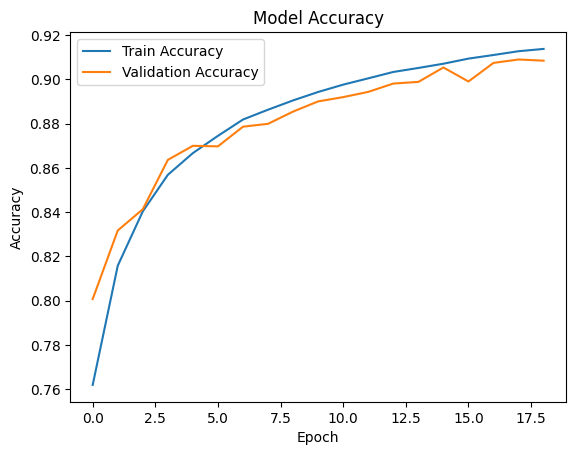

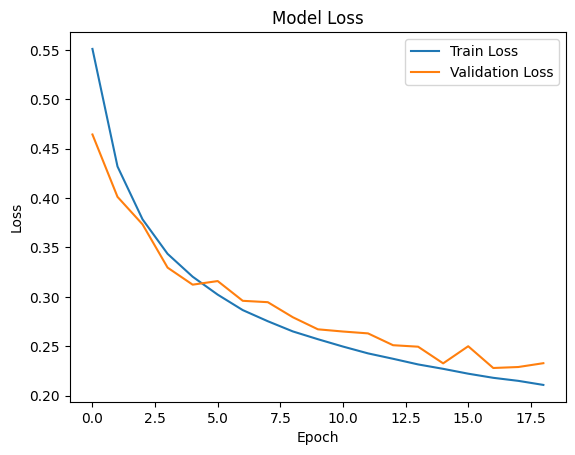

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('accuracy_plot.png')  # Save as PNG
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_plot.png')  # Save as PNG
plt.show()

In [ ]:
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(y_pred)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

3596/3596 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
[2 2 1 ... 2 2 2]
              precision    recall  f1-score   support

           1       0.92      0.90      0.91     42320
           2       0.92      0.93      0.92     56512
           3       0.87      0.91      0.89      6341
           4       0.91      0.61      0.74       488
           5       0.83      0.70      0.76      1917
           6       0.81      0.79      0.80      3413
           7       0.90      0.92      0.91      4050

    accuracy                           0.91    115041
   macro avg       0.88      0.82      0.85    115041
weighted avg       0.91      0.91      0.91    115041



#Create 100k datasets for tuning purpose

In [ ]:
# ================================
# Create 100k tuning subset
# ================================

TUNE_SIZE = 100000

X_tune = X_no_outliers.sample(TUNE_SIZE, random_state=42)
y_tune = y_no_outliers.loc[X_tune.index]

print("Tuning dataset size:", X_tune.shape[0])


Tuning dataset size: 100000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate numerical & categorical features for tuning subset
X_tune_num = X_tune[num_sel]
X_tune_cat = X_tune[cat_sel]

# Scale only numerical features
scaler_tune = StandardScaler()
X_tune_num_sc = scaler_tune.fit_transform(X_tune_num)

# Combine scaled numerical + categorical
X_tune_sc = np.hstack([X_tune_num_sc, X_tune_cat.values])

X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_tune_sc, y_tune, test_size=0.2, random_state=42
)

print(X_tune_train.shape, X_tune_val.shape)

(80000, 20) (20000, 20)


Build Model (SDG and Adam)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(optimizer, lr):
    if optimizer == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=lr)
    elif optimizer == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model = Sequential([
        Dense(256, activation='relu', input_dim=X_tune_train.shape[1]),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(8, activation='softmax')
    ])

    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


## Step 2 Tune SGD

#Learning Rate for SGD

1.   lr = 0.1
2.   lr = 0.01
3.   lr = 0.001

In [ ]:
# Learning rate, fixed batch size 32, epoch=20
# Use 100k dataset
import tensorflow as tf

sgd_lrs = [0.1, 0.01, 0.001]
sgd_lr_results = {}

for lr in sgd_lrs:
    model = build_model("sgd", lr)
    history = model.fit(
        X_tune_train, y_tune_train,
        epochs=20, batch_size=32, verbose=0,
        validation_data=(X_tune_val, y_tune_val)
    )
    acc = max(history.history['val_accuracy'])
    sgd_lr_results[lr] = acc
    print(f"SGD LR={lr} → Best Val Acc = {acc:.4f}")

# Automatically determine the best learning rate
best_lr_sgd = max(sgd_lr_results, key=sgd_lr_results.get)
best_acc_sgd = sgd_lr_results[best_lr_sgd]

# Add the best info into the results dictionary
sgd_lr_results['best'] = {'lr': best_lr_sgd, 'val_accuracy': best_acc_sgd}

print("\nFinal SGD LR Results:")
print(sgd_lr_results)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD LR=0.1 → Best Val Acc = 0.8481
SGD LR=0.01 → Best Val Acc = 0.7939
SGD LR=0.001 → Best Val Acc = 0.7270

Final SGD LR Results:
{0.1: 0.8481000065803528, 0.01: 0.7938500046730042, 0.001: 0.7269999980926514, 'best': {'lr': 0.1, 'val_accuracy': 0.8481000065803528}}


#Batch Size for SGD


1.   Batch size = 32
2.   Batch size = 64
3.   Batch size = 128



In [ ]:
# Train batch size
# Use 100k dataset
sgd_batch_sizes = [32, 64, 128]
sgd_bs_results = {}

# Get the best learning rate from previous tuning
best_lr_sgd = sgd_lr_results['best']['lr']

for bs in sgd_batch_sizes:
    model = build_model("sgd", best_lr_sgd)
    history = model.fit(
        X_tune_train, y_tune_train,
        epochs=20, batch_size=bs, verbose=0,
        validation_data=(X_tune_val, y_tune_val)
    )
    acc = max(history.history['val_accuracy'])
    sgd_bs_results[bs] = acc
    print(f"SGD Batch={bs} → Best Val Acc = {acc:.4f}")

# Automatically determine the best batch size
best_bs_sgd = max(sgd_bs_results, key=sgd_bs_results.get)
best_bs_acc_sgd = sgd_bs_results[best_bs_sgd]

# Add the best info into the results dictionary
sgd_bs_results['best'] = {'batch_size': best_bs_sgd, 'val_accuracy': best_bs_acc_sgd}

print("\nFinal SGD Batch Size Results:")
print(sgd_bs_results)


SGD Batch=32 → Best Val Acc = 0.8479
SGD Batch=64 → Best Val Acc = 0.8343
SGD Batch=128 → Best Val Acc = 0.8091

Final SGD Batch Size Results:
{32: 0.8478999733924866, 64: 0.8342999815940857, 128: 0.8090999722480774, 'best': {'batch_size': 32, 'val_accuracy': 0.8478999733924866}}


#Vary Epoch for SGD
1. epoch = 10
2. epoch = 20
3. epoch = 30
4. epoch = 40

In [ ]:
#choose the best epoch count
# use 100k dataset
# Choose the best epoch count
sgd_epochs = [10, 20, 30, 40]
sgd_epoch_results = {}

# Get the best batch size from previous results
best_bs_sgd = sgd_bs_results['best']['batch_size']

for ep in sgd_epochs:
    model = build_model("sgd", best_lr_sgd)
    history = model.fit(
        X_tune_train, y_tune_train,
        epochs=ep, batch_size=best_bs_sgd, verbose=0,
        validation_data=(X_tune_val, y_tune_val)
    )
    acc = max(history.history['val_accuracy'])
    sgd_epoch_results[ep] = acc
    print(f"SGD Epoch={ep} → Best Val Acc = {acc:.4f}")

# Select best epoch
best_epoch_sgd = max(sgd_epoch_results, key=sgd_epoch_results.get)
print("\nBest SGD epoch =", best_epoch_sgd)



SGD Epoch=10 → Best Val Acc = 0.8155
SGD Epoch=20 → Best Val Acc = 0.8436
SGD Epoch=30 → Best Val Acc = 0.8634
SGD Epoch=40 → Best Val Acc = 0.8699

Best SGD epoch = 40


# Train SGD

In [ ]:
best_epoch_sgd = max(sgd_epoch_results, key=sgd_epoch_results.get)

# Separate numerical & categorical features
X_num_sel = X_num_no_outliers[num_sel]      # selected numerical features
X_cat_sel = X_cat_no_outliers[cat_sel]      # selected categorical one-hot features

# Scale numerical features only
scaler_full = StandardScaler()
X_num_scaled = scaler_full.fit_transform(X_num_sel)

# Combine scaled numerical + categorical
X_full = np.hstack([X_num_scaled, X_cat_sel.values])

# Train-test split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_no_outliers, test_size=0.2, random_state=42
)

# Build and train model
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

model_sgd_final = build_model("sgd", best_lr_sgd)

history_sgd = model_sgd_final.fit(
    X_train_full, y_train_full,
    epochs=best_epoch_sgd,
    batch_size=best_bs_sgd,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11504/11504 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.7205 - loss: 0.6522 - val_accuracy: 0.7811 - val_loss: 0.5080
Epoch 2/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.7929 - loss: 0.4857 - val_accuracy: 0.8073 - val_loss: 0.4538
Epoch 3/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8221 - loss: 0.4197 - val_accuracy: 0.8307 - val_loss: 0.3981
Epoch 4/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.8411 - loss: 0.3785 - val_accuracy: 0.8466 - val_loss: 0.3710
Epoch 5/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.8529 - loss: 0.3526 - val_accuracy: 0.8584 - val_loss: 0.3421
Epoch 6/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8610 - loss: 0.3332 - val_accuracy: 0.8683 - val_loss: 0.3201
Epoch 7/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8691 - loss: 0.3171 - val_accuracy: 0.8733 - val_loss: 0.3106
Epoch 8/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8743 - lo

#Adam

#Learning Rate for Adam

1.   lr = 0.01
2.   lr = 0.001
3.   lr = 0.0001

In [ ]:
# Learning rate, fixed batch size 32, epoch=20
# Use 100k dataset
adam_lrs = [0.01, 0.001, 0.0001]
adam_lr_results = {}

for lr in adam_lrs:
    model = build_model("adam", lr)
    history = model.fit(
        X_tune_train, y_tune_train,
        epochs=20, batch_size=32, verbose=0,
        validation_data=(X_tune_val, y_tune_val)
    )
    acc = max(history.history['val_accuracy'])
    adam_lr_results[lr] = acc
    print(f"Adam LR={lr} → Best Val Acc = {acc:.4f}")

# Automatically determine the best learning rate
best_lr = max(adam_lr_results, key=adam_lr_results.get)
best_acc = adam_lr_results[best_lr]

# Add the best info into the results dictionary
adam_lr_results['best'] = {'lr': best_lr, 'val_accuracy': best_acc}

print("\nFinal Adam LR Results:")
print(adam_lr_results)


Adam LR=0.01 → Best Val Acc = 0.8067
Adam LR=0.001 → Best Val Acc = 0.8630
Adam LR=0.0001 → Best Val Acc = 0.7947

Final Adam LR Results:
{0.01: 0.8066999912261963, 0.001: 0.8629999756813049, 0.0001: 0.794700026512146, 'best': {'lr': 0.001, 'val_accuracy': 0.8629999756813049}}


#Batch Size for Adam


1.   Batch size = 32
2.   Batch size = 64
3.   Batch size = 128

In [ ]:
# Train batch size
# Use 100k dataset
adam_batch_sizes = [32, 64, 128]
adam_bs_results = {}

# Get the best learning rate from previous tuning
best_lr_adam = adam_lr_results['best']['lr']

for bs in adam_batch_sizes:
    model = build_model("adam", best_lr_adam)
    history = model.fit(
        X_tune_train, y_tune_train,
        epochs=20, batch_size=bs, verbose=0,
        validation_data=(X_tune_val, y_tune_val)
    )
    acc = max(history.history['val_accuracy'])
    adam_bs_results[bs] = acc
    print(f"Adam Batch={bs} → Best Val Acc = {acc:.4f}")

# Automatically determine the best batch size
best_bs_adam = max(adam_bs_results, key=adam_bs_results.get)
best_bs_acc = adam_bs_results[best_bs_adam]

# Add the best info into the results dictionary
adam_bs_results['best'] = {'batch_size': best_bs_adam, 'val_accuracy': best_bs_acc}

print("\nFinal Adam Batch Size Results:")
print(adam_bs_results)


Adam Batch=32 → Best Val Acc = 0.8587
Adam Batch=64 → Best Val Acc = 0.8527
Adam Batch=128 → Best Val Acc = 0.8409

Final Adam Batch Size Results:
{32: 0.8587499856948853, 64: 0.8526999950408936, 128: 0.8409000039100647, 'best': {'batch_size': 32, 'val_accuracy': 0.8587499856948853}}


Vary Epoch for Adam
epoch = 10
epoch = 20
epoch = 30
epoch = 40

In [ ]:
# Choose the best epoch count
# Use 100k dataset
adam_epochs = [10, 20, 30, 40]
adam_epoch_results = {}

# Get the best batch size from previous tuning
best_bs_adam = adam_bs_results['best']['batch_size']

for ep in adam_epochs:
    model = build_model("adam", best_lr_adam)
    history = model.fit(
        X_tune_train, y_tune_train,
        epochs=ep, batch_size=best_bs_adam, verbose=0,
        validation_data=(X_tune_val, y_tune_val)
    )
    acc = max(history.history['val_accuracy'])
    adam_epoch_results[ep] = acc
    print(f"Adam Epoch={ep} → Best Val Acc = {acc:.4f}")

# Automatically determine the best epoch count
best_epoch_adam = max(adam_epoch_results, key=adam_epoch_results.get)
best_epoch_acc = adam_epoch_results[best_epoch_adam]

# Add the best info into the results dictionary
adam_epoch_results['best'] = {'epochs': best_epoch_adam, 'val_accuracy': best_epoch_acc}

print("\nFinal Adam Epoch Results:")
print(adam_epoch_results)


Adam Epoch=10 → Best Val Acc = 0.8360
Adam Epoch=20 → Best Val Acc = 0.8558
Adam Epoch=30 → Best Val Acc = 0.8713
Adam Epoch=40 → Best Val Acc = 0.8841

Final Adam Epoch Results:
{10: 0.8360499739646912, 20: 0.8557999730110168, 30: 0.8713499903678894, 40: 0.8841000199317932, 'best': {'epochs': 40, 'val_accuracy': 0.8841000199317932}}


## Train Adam

In [ ]:
# Get best hyperparameters from tuning results
best_bs_adam = adam_bs_results['best']['batch_size']
best_epoch_adam = adam_epoch_results['best']['epochs']

# Build final Adam model
model_adam_final = build_model("adam", best_lr_adam)

# Train on full dataset with early stopping
history_adam = model_adam_final.fit(
    X_train_full, y_train_full,
    epochs=best_epoch_adam,
    batch_size=best_bs_adam,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.7353 - loss: 0.6232 - val_accuracy: 0.7963 - val_loss: 0.4734
Epoch 2/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.8106 - loss: 0.4434 - val_accuracy: 0.8346 - val_loss: 0.3953
Epoch 3/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.8402 - loss: 0.3810 - val_accuracy: 0.8524 - val_loss: 0.3548
Epoch 4/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.8566 - loss: 0.3439 - val_accuracy: 0.8589 - val_loss: 0.3389
Epoch 5/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.8681 - loss: 0.3180 - val_accuracy: 0.8690 - val_loss: 0.3148
Epoch 6/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.8760 - loss: 0.2991 - val_accuracy: 0.8792 - val_loss: 0.2947
Epoch 7/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.8827 - loss: 0.2817 - val_accuracy: 0.8821 - val_loss: 0.2901
Epoch 8/40
11504/11504 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 

# Compare Final SGD vs Final Adam

In [ ]:
#Best SGD and Adam validation accuracy
print("Best SGD validation accuracy:", max(history_sgd.history['val_accuracy']))
print("Best Adam validation accuracy:", max(history_adam.history['val_accuracy']))

Best SGD validation accuracy: 0.9082819223403931
Best Adam validation accuracy: 0.9168224334716797


In [ ]:
# Compare Training Time for SGD and Adam
import time

# ===== Measure SGD Training Time =====
start_sgd = time.time()

model_sgd_final = build_model("sgd", best_lr_sgd)
history_sgd = model_sgd_final.fit(
    X_train_full, y_train_full,
    epochs=best_epoch_sgd,
    batch_size=best_bs_sgd,
    validation_split=0.2,
    callbacks=[es],
    verbose=0
)

end_sgd = time.time()
sgd_time = end_sgd - start_sgd
print(f"SGD Training Time: {sgd_time:.2f} seconds")


# ===== Measure Adam Training Time =====
start_adam = time.time()

model_adam_final = build_model("adam", best_lr_adam)
history_adam = model_adam_final.fit(
    X_train_full, y_train_full,
    epochs=best_epoch_adam,
    batch_size=best_bs_adam,
    validation_split=0.2,
    callbacks=[es],
    verbose=0
)

end_adam = time.time()
adam_time = end_adam - start_adam
print(f"Adam Training Time: {adam_time:.2f} seconds")


# ===== Summary =====
print("\n=== Training Time Comparison ===")
print(f"SGD  : {sgd_time:.2f} seconds")
print(f"Adam : {adam_time:.2f} seconds")

if sgd_time > adam_time:
    print("➡ Adam trains faster than SGD")
else:
    print("➡ SGD trains faster than Adam")


SGD Training Time: 664.77 seconds
Adam Training Time: 942.38 seconds

=== Training Time Comparison ===
SGD  : 664.77 seconds
Adam : 942.38 seconds
➡ SGD trains faster than Adam


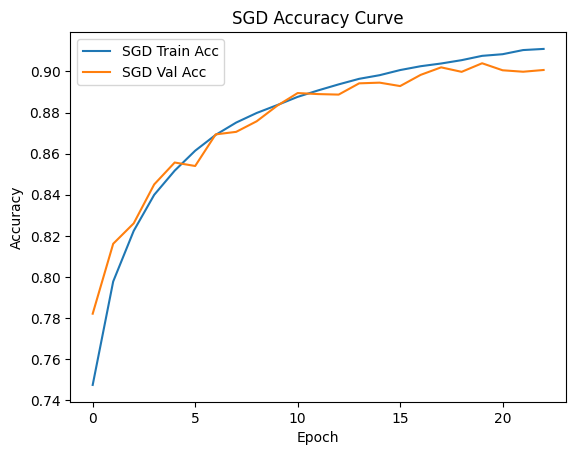

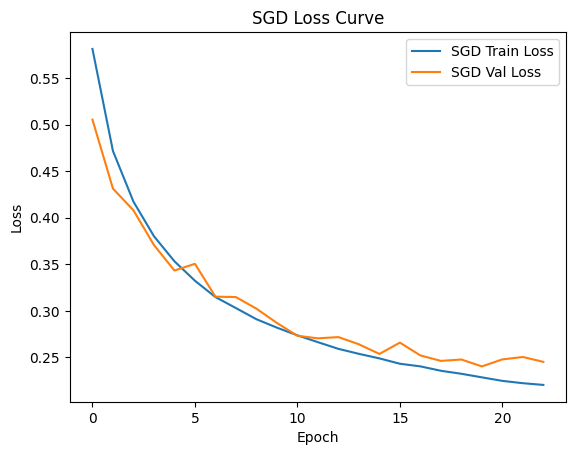

In [ ]:
# Training and loss curve for SGD
import matplotlib.pyplot as plt

# ----- Accuracy Curve -----
plt.plot(history_sgd.history['accuracy'], label="SGD Train Acc")
plt.plot(history_sgd.history['val_accuracy'], label="SGD Val Acc")
plt.legend()
plt.title("SGD Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# ----- Loss Curve -----
plt.plot(history_sgd.history['loss'], label="SGD Train Loss")
plt.plot(history_sgd.history['val_loss'], label="SGD Val Loss")
plt.legend()
plt.title("SGD Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


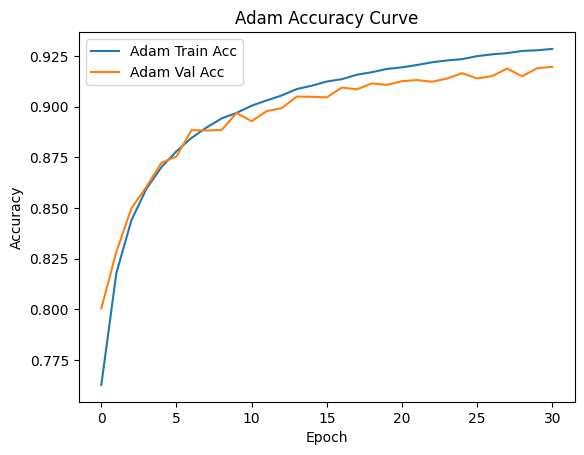

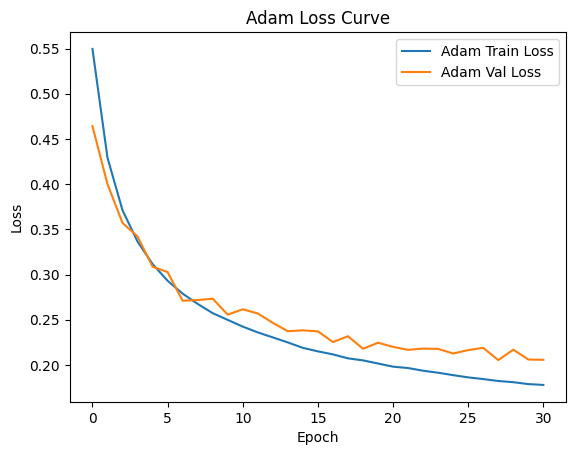

In [ ]:
# Training and loss curve for Adam
import matplotlib.pyplot as plt

# ----- Accuracy Curve -----
plt.plot(history_adam.history['accuracy'], label="Adam Train Acc")
plt.plot(history_adam.history['val_accuracy'], label="Adam Val Acc")
plt.legend()
plt.title("Adam Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# ----- Loss Curve -----
plt.plot(history_adam.history['loss'], label="Adam Train Loss")
plt.plot(history_adam.history['val_loss'], label="Adam Val Loss")
plt.legend()
plt.title("Adam Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


##Part 3

Save the model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Create folder in Drive
save_dir = "/content/drive/MyDrive/ML_model"
os.makedirs(save_dir, exist_ok=True)

# Save models
model.save(f"{save_dir}/baseline_model.h5")
model_sgd_final.save(f"{save_dir}/sgd_best_model.h5")
model_adam_final.save(f"{save_dir}/adam_best_model.h5")

print("Models saved successfully in ML_model folder.")

Mounted at /content/drive


Models saved successfully in ML_model folder.


Load back the model

In [ ]:
from tensorflow.keras.models import load_model

save_dir = "/content/drive/MyDrive/ML_model"

baseline_loaded = load_model(f"{save_dir}/baseline_model.h5")
sgd_loaded = load_model(f"{save_dir}/sgd_best_model.h5")
adam_loaded = load_model(f"{save_dir}/adam_best_model.h5")

print("Models loaded successfully.")


Models loaded successfully.


Make predictions from each

In [ ]:
import numpy as np

pred_base = np.argmax(baseline_loaded.predict(X_test_full), axis=1)
pred_sgd  = np.argmax(sgd_loaded.predict(X_test_full), axis=1)
pred_adam = np.argmax(adam_loaded.predict(X_test_full), axis=1)

print("Predictions completed.")


3596/3596 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
3596/3596 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3596/3596 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Predictions completed.


Hard Voting Ensemble

In [ ]:
# Combine into matrix shape: (num_samples, 3)
preds = np.vstack([pred_base, pred_sgd, pred_adam]).T

# Hard vote using mode
from scipy.stats import mode
hard_vote_pred, _ = mode(preds, axis=1)

hard_vote_pred = hard_vote_pred.flatten()

print("Hard voting completed.")


Hard voting completed.


Soft Voting Ensemble

In [ ]:
# Get actual probability outputs
p_base = baseline_loaded.predict(X_test_full)
p_sgd  = sgd_loaded.predict(X_test_full)
p_adam = adam_loaded.predict(X_test_full)

# Average probabilities
soft_prob = (p_base + p_sgd + p_adam) / 3

soft_vote_pred = np.argmax(soft_prob, axis=1)

print("Soft voting completed.")


3596/3596 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
3596/3596 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3596/3596 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Soft voting completed.


Compare accuracies

In [ ]:
from sklearn.metrics import accuracy_score

acc_base = accuracy_score(y_test_full, pred_base)
acc_sgd  = accuracy_score(y_test_full, pred_sgd)
acc_adam = accuracy_score(y_test_full, pred_adam)

acc_hard = accuracy_score(y_test_full, hard_vote_pred)
acc_soft = accuracy_score(y_test_full, soft_vote_pred)

print("=== Accuracy Comparison ===")
print(f"Baseline MLP Accuracy : {acc_base:.4f}")
print(f"SGD Best Accuracy     : {acc_sgd:.4f}")
print(f"Adam Best Accuracy    : {acc_adam:.4f}")
print(f"Ensemble Hard Voting  : {acc_hard:.4f}")
print(f"Ensemble Soft Voting  : {acc_soft:.4f}")


=== Accuracy Comparison ===
Baseline MLP Accuracy : 0.9061
SGD Best Accuracy     : 0.9032
Adam Best Accuracy    : 0.9195
Ensemble Hard Voting  : 0.9290
Ensemble Soft Voting  : 0.9328


Confusion Matrix (Best Model)

In [ ]:
# Only compare individual MLP models
acc_results_mlp = {
    "baseline": acc_base,
    "sgd": acc_sgd,
    "adam": acc_adam
}

best_model_name = max(acc_results_mlp, key=acc_results_mlp.get)
print("Best individual MLP model:", best_model_name)

# Pick prediction array of the best individual model
best_pred = {
    "baseline": pred_base,
    "sgd": pred_sgd,
    "adam": pred_adam
}[best_model_name]


Best individual MLP model: adam


Plot confusion matrix


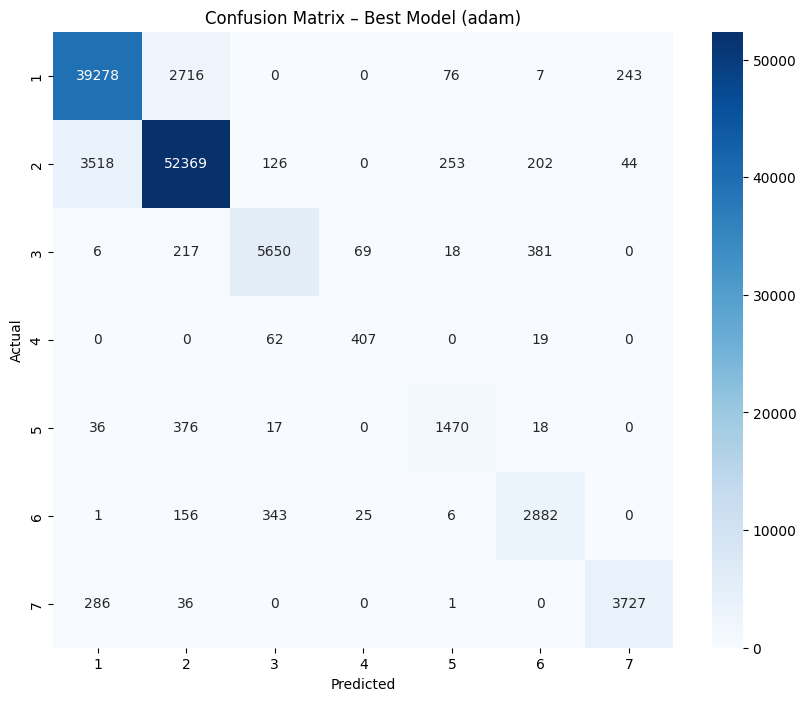

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Specify labels to match target values 1-7
labels = [1, 2, 3, 4, 5, 6, 7]

# Compute confusion matrix with correct labels
cm = confusion_matrix(y_test_full, best_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix – Best Model ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()